In [1]:
import os
import glob
import pandas as pd
import ast
import math
import re

## Prep data (continue if already done)

In [2]:
included_df = pd.read_csv("../07_full_text_retrieval/cadmus/successfully_retrieved_PMIDs_UoZ.csv")

/sctmp/sdonev/ipykernel_3901844/2537709987.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  included_df = pd.read_csv("../07_full_text_retrieval/cadmus/successfully_retrieved_PMIDs_UoZ.csv")


In [3]:
included_df.shape

(340418, 2)

In [4]:
included_df.head()

,PMID,source_label
0,10063484,cadmus
1,10068158,cadmus
2,10068163,cadmus
3,10068171,cadmus
4,10068174,cadmus


In [5]:
def add_column_from_folder(included_df, folder, file_glob="*.csv",
                           pmid_col="PMID", new_col="Text"):
    """
    Adds a new column from CSVs in a folder to included_df.
    
    Parameters:
    -----------
    included_df : pd.DataFrame
        DataFrame containing a column of PMIDs
    folder : str
        Directory with CSV files
    file_glob : str
        Filename pattern to match (default "*.csv")
    pmid_col : str
        Name of the PMID column in both included_df and CSVs
    new_col : str
        Name of the column to bring over from the CSVs
    
    Returns:
    --------
    merged : pd.DataFrame
        Copy of included_df with the new column added (NaN if not found).
    """
    included_df = included_df.copy()
    included_df[pmid_col] = included_df[pmid_col].astype(str).str.strip()
    included_pmids = set(included_df[pmid_col])

    all_paths = sorted(glob.glob(os.path.join(folder, file_glob)))
    if not all_paths:
        raise FileNotFoundError(f"No files matched: {os.path.join(folder, file_glob)}")

    kept = []
    rows_scanned = rows_matched = 0

    for p in all_paths:
        df = pd.read_csv(p, dtype={pmid_col: str})
        if not {pmid_col, new_col}.issubset(df.columns):
            print(f"Skipping {os.path.basename(p)} (missing {new_col})")
            continue
        df[pmid_col] = df[pmid_col].astype(str).str.strip()

        rows_scanned += len(df)
        sub = df[df[pmid_col].isin(included_pmids)][[pmid_col, new_col]].copy()
        rows_matched += len(sub)

        if not sub.empty:
            kept.append(sub)

    if kept:
        combined = pd.concat(kept, ignore_index=True)
        combined = combined.drop_duplicates(subset=[pmid_col], keep="first")
    else:
        combined = pd.DataFrame(columns=[pmid_col, new_col])

    merged = included_df.merge(combined, on=pmid_col, how="left")

    # --- Stats ---
    n_total = len(included_df)
    n_found = merged[new_col].notna().sum()
    n_missing = n_total - n_found
    print(f"Scanned {len(all_paths)} file(s), {rows_scanned:,} rows in total.")
    print(f"Matched {rows_matched:,} rows for {new_col}.")
    print(f"Out of {n_total:,} included PMIDs: {n_found:,} had {new_col}, {n_missing:,} missing.")

    return merged


In [7]:
included_with_preds = add_column_from_folder(
    included_df,
    folder="/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/model_predictions/drug_disease",
    new_col="ner_prediction_BioLinkBERT-base_normalized",
    file_glob="test_annotated_BioLinkBERT-base_tuples_*.csv"
)

Scanned 617 file(s), 6,160,794 rows in total.
Matched 342,339 rows for ner_prediction_BioLinkBERT-base_normalized.
Out of 340,418 included PMIDs: 334,607 had ner_prediction_BioLinkBERT-base_normalized, 5,811 missing.


In [8]:
included_with_preds.shape

(340418, 3)

In [9]:
included_with_preds.head()

,PMID,source_label,ner_prediction_BioLinkBERT-base_normalized
0,10063484,cadmus,"[(76, 97, 'DISEASE', 'immobilization stress'),..."
1,10068158,cadmus,"[(145, 165, 'DISEASE', 'thermal hyperalgesia')..."
2,10068163,cadmus,"[(11, 24, 'DRUG', 'kappa opioids'), (152, 182,..."
3,10068171,cadmus,"[(4, 33, 'DRUG', 'kappa opioid agonist gr89 , ..."
4,10068174,cadmus,"[(42, 69, 'DISEASE', 'trigeminal neuropathic p..."


In [10]:
included_with_preds_text = add_column_from_folder(
    included_with_preds,
    folder="/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/data/animal_studies_for_ner/",
    new_col="Text"
)

Scanned 617 file(s), 6,160,794 rows in total.
Matched 342,339 rows for Text.
Out of 340,418 included PMIDs: 334,607 had Text, 5,811 missing.


In [11]:
included_with_preds_text.head()

,PMID,source_label,ner_prediction_BioLinkBERT-base_normalized,Text
0,10063484,cadmus,"[(76, 97, 'DISEASE', 'immobilization stress'),...",The Ca2+ channel blockade changes the behavior...
1,10068158,cadmus,"[(145, 165, 'DISEASE', 'thermal hyperalgesia')...",Lack of involvement of capsaicin-sensitive pri...
2,10068163,cadmus,"[(11, 24, 'DRUG', 'kappa opioids'), (152, 182,...",Effects of kappa opioids in the inflamed rat c...
3,10068171,cadmus,"[(4, 33, 'DRUG', 'kappa opioid agonist gr89 , ...","The kappa opioid agonist GR89,696 blocks hyper..."
4,10068174,cadmus,"[(42, 69, 'DISEASE', 'trigeminal neuropathic p...",Pharmacological studies on a rat model of trig...


In [12]:
included_with_preds_text.to_csv("combined_included_data.csv",index=False)

In [13]:
included_with_preds_text.iloc[4]['Text'][42:69]

'trigeminal neuropathic pain'

## Check prevalence of entities in title

In [2]:
included_with_preds_text = pd.read_csv("combined_included_data.csv")

/sctmp/sdonev/ipykernel_1837655/2465212515.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  included_with_preds_text = pd.read_csv("combined_included_data.csv")


In [3]:
norm_entities = pd.read_csv("/data/sdonev/preclin_ner_normalization/mapped_to_embeddings_ontologies/preclinical_merged/drug_disease_mapped_preclinical.csv")


In [4]:
norm_entities['PMID'] = norm_entities['PMID'].astype(str)
included_with_preds_text['PMID'] = included_with_preds_text['PMID'].astype(str)


In [5]:
norm_entities[norm_entities['PMID']=='10068163']

,PMID,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid
388238,10068163,colitis|inflammatory bowel disease,MONDO:0005292|MONDO:0005265,delta-ora|kappa-oras|Morphine|Naloxone|kappa o...,-1|-1|C0026549|C0027358|-1|C0294405|C0165396|-...


In [6]:
included_with_preds_text = included_with_preds_text.merge(norm_entities[['PMID','disease_term_mondo_norm','disease_mondo_termid','drug_term_umls_norm', 'drug_umls_termid']], how='left',on='PMID')


In [7]:
included_with_preds_text['Text'] = included_with_preds_text['Text'].fillna("")

In [8]:
included_with_preds_text['title'] = included_with_preds_text['Text'].apply(lambda x: x.split("|")[0])

In [9]:
included_with_preds_text.head()

,PMID,source_label,ner_prediction_BioLinkBERT-base_normalized,Text,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,title
0,10063484,cadmus,"[(76, 97, 'DISEASE', 'immobilization stress'),...",The Ca2+ channel blockade changes the behavior...,immobilization stress,-1,Calcium Channels|Nifedipine,C0006685|C0028066,The Ca2+ channel blockade changes the behavior...
1,10068158,cadmus,"[(145, 165, 'DISEASE', 'thermal hyperalgesia')...",Lack of involvement of capsaicin-sensitive pri...,neuralgia|tactile|thermal hyperalgesia,MONDO:0021667|-1|-1,Morphine|Capsaicin|resiniferatoxin,C0026549|C0006931|C0073081,Lack of involvement of capsaicin-sensitive pri...
2,10068163,cadmus,"[(11, 24, 'DRUG', 'kappa opioids'), (152, 182,...",Effects of kappa opioids in the inflamed rat c...,colitis|inflammatory bowel disease,MONDO:0005292|MONDO:0005265,delta-ora|kappa-oras|Morphine|Naloxone|kappa o...,-1|-1|C0026549|C0027358|-1|C0294405|C0165396|-...,Effects of kappa opioids in the inflamed rat c...
3,10068171,cadmus,"[(4, 33, 'DRUG', 'kappa opioid agonist gr89 , ...","The kappa opioid agonist GR89,696 blocks hyper...",neuritis|hyperalgesia and allodynia|peripheral...,MONDO:0002122|-1|MONDO:0005244|MONDO:0044745|-...,kappa-1 agonist u69593|GR 89696|kappa-2 opioid...,-1|C0120253|-1|-1|C0120253|C0027358,"The kappa opioid agonist GR89,696 blocks hyper..."
4,10068174,cadmus,"[(42, 69, 'DISEASE', 'trigeminal neuropathic p...",Pharmacological studies on a rat model of trig...,trigeminal paraesthesias|neuralgia|trigeminal ...,-1|MONDO:0021667|MONDO:0008599,tricyclic antidepressants|Clomipramine|Baclofe...,-1|C0009010|C0004609|C0026549|C0006949|C008197...,Pharmacological studies on a rat model of trig...


In [10]:
included_with_preds_text.iloc[2]['disease_term_mondo_norm'], included_with_preds_text.iloc[2]['disease_mondo_termid']

('colitis|inflammatory bowel disease', 'MONDO:0005292|MONDO:0005265')

In [11]:
included_with_preds_text.iloc[2]['drug_term_umls_norm'], included_with_preds_text.iloc[2]['drug_umls_termid']

('delta-ora|kappa-oras|Morphine|Naloxone|kappa opioids|EMD 61753|ICI 204448|kappa-opioid receptor agonists|non-opioid receptor-selective|SNC 80|Morphine|delta-ora snc 80|oras|mu-receptor -',
 '-1|-1|C0026549|C0027358|-1|C0294405|C0165396|-1|-1|C0257309|C0026549|-1|-1|-1')

In [12]:
NER_COL = "ner_prediction_BioLinkBERT-base_normalized"


In [13]:
def to_list_of_ents(x):
    # NaN/None → []
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return []
    # Strings like "[(...)]" → parsed safely
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (SyntaxError, ValueError):
            return []
    # Single tuple → wrap in list
    if isinstance(x, tuple):
        return [x]
    # Already a list → keep
    if isinstance(x, list):
        return x
    # Anything else → []
    return []

# Coerce the column once


In [14]:
included_with_preds_text[NER_COL] = included_with_preds_text[NER_COL].apply(to_list_of_ents)
included_with_preds_text_analysis = included_with_preds_text.copy()


In [15]:
APOS_RX = re.compile(r"(?<=\w)\s*(['’])\s*(?=\w)")
DASH_RX = re.compile(r"(?<=\w)\s*([-–—−])\s*(?=\w)")
SLASH_RX = re.compile(r"(?<=\S)\s*/\s*(?=\S)")    

def normalize_punct_spacing(s: str, normalize_dash: bool = True) -> str:
    if s is None:
        return s
    s = str(s)
    # normalize apostrophes: alzheimer ' s -> alzheimer's
    s = APOS_RX.sub("'", s)
    # normalize dashes: kappa - opioid -> kappa-opioid
    s = DASH_RX.sub("-" if normalize_dash else r"\1", s)
    s = SLASH_RX.sub("/", s)   
    return s
    
def match_entities_in_title(row):
    title = row.get("title") or ""
    ents = row.get(NER_COL)

    # title (unique, order-preserving)
    disease_title_seen, drug_title_seen = set(), set()
    disease_in_title, drug_in_title = [], []

    # abstract (unique sets + order-preserving lists)
    disease_abs_seen, drug_abs_seen = set(), set()
    disease_in_abstract, drug_in_abstract = [], []

    for item in ents:
        # expect (start, end, label, text)
        if not (isinstance(item, (list, tuple)) and len(item) >= 4):
            continue
        start, end, label, text = item[:4]
        
        #print(len(title),title)

        if label not in ("DISEASE", "DRUG"):
            continue

        # Decide title vs abstract using indices
        in_title = (
            isinstance(start, int) and isinstance(end, int) and
            0 <= start < end <= len(title)
        )

        if in_title:
            #print("IN TITLE")
            #print(start, end, label, text)
            span = title[start:end]
          
            text = normalize_punct_spacing(text)
            if span == text or span.lower() == str(text).lower():
                # title match
                if label == "DISEASE":
                    if text not in disease_title_seen:
                        disease_title_seen.add(text)
                        disease_in_title.append(text)
                else:  # DRUG
                    if text not in drug_title_seen:
                        drug_title_seen.add(text)
                        drug_in_title.append(text)
                continue  # don’t also count it as abstract

        # abstract (anything not matched in title slice)
        if label == "DISEASE":
            if text not in disease_abs_seen:
                disease_abs_seen.add(text)
                disease_in_abstract.append(text)
        else:
            if text not in drug_abs_seen:
                drug_abs_seen.add(text)
                drug_in_abstract.append(text)

    return pd.Series({
        "count_disease_in_title": len(disease_title_seen),
        "count_drug_in_title": len(drug_title_seen),
        "disease_in_title": disease_in_title,      # unique, order-preserving
        "drug_in_title": drug_in_title,            # unique, order-preserving
        "count_disease_in_abstract": len(disease_abs_seen),
        "count_drug_in_abstract": len(drug_abs_seen),
        "disease_in_abstract": disease_in_abstract,  # unique, order-preserving
        "drug_in_abstract": drug_in_abstract,        # unique, order-preserving
    })

In [16]:
out = included_with_preds_text_analysis.apply(match_entities_in_title, axis=1)
included_with_preds_text_analysis[out.columns] = out

In [19]:
included_with_preds_text_analysis.to_csv("ds_analyse_entities_in_title.csv",index=False)

In [18]:
included_with_preds_text_analysis[included_with_preds_text_analysis['PMID']=="19193873"]

,PMID,source_label,ner_prediction_BioLinkBERT-base_normalized,Text,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,title,count_disease_in_title,count_drug_in_title,disease_in_title,drug_in_title,count_disease_in_abstract,count_drug_in_abstract,disease_in_abstract,drug_in_abstract
228903,19193873,bioc_json,"[(36, 37, DRUG, 1), (90, 110, DISEASE, hunting...","Neuroprotective effects of inositol 1,4,5-tris...",Huntington disease,MONDO:0007739,ic10,-1,"Neuroprotective effects of inositol 1,4,5-tris...",1,1,[huntington's disease],[1],2,1,"[huntington ' s disease, hd]",[ic10]


In [81]:
row_ex = included_with_preds_text_analysis[included_with_preds_text_analysis['PMID']==19193873]
match_entities_in_title(row_ex.iloc[0])

count_disease_in_title        0
count_drug_in_title           0
disease_in_title             []
drug_in_title                []
count_disease_in_abstract     0
count_drug_in_abstract        0
disease_in_abstract          []
drug_in_abstract             []
dtype: object

## Viz entitites distribution

In [73]:
included_with_preds_text_analysis = pd.read_csv("ds_analyse_entities_in_title.csv")

/sctmp/sdonev/ipykernel_1831071/1542456732.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  included_with_preds_text_analysis = pd.read_csv("ds_analyse_entities_in_title.csv")


In [20]:
included_with_preds_text_analysis.head() 

,PMID,source_label,ner_prediction_BioLinkBERT-base_normalized,Text,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,title,count_disease_in_title,count_drug_in_title,disease_in_title,drug_in_title,count_disease_in_abstract,count_drug_in_abstract,disease_in_abstract,drug_in_abstract
0,10063484,cadmus,"[(76, 97, DISEASE, immobilization stress), (14...",The Ca2+ channel blockade changes the behavior...,immobilization stress,-1,Calcium Channels|Nifedipine,C0006685|C0028066,The Ca2+ channel blockade changes the behavior...,1,0,[immobilization stress],[],1,2,[immobilization stress],"[ca2 + channel, nifedipine]"
1,10068158,cadmus,"[(145, 165, DISEASE, thermal hyperalgesia), (1...",Lack of involvement of capsaicin-sensitive pri...,neuralgia|tactile|thermal hyperalgesia,MONDO:0021667|-1|-1,Morphine|Capsaicin|resiniferatoxin,C0026549|C0006931|C0073081,Lack of involvement of capsaicin-sensitive pri...,0,0,[],[],4,4,"[thermal hyperalgesia, neuropathic pain, tacti...","[resiniferatoxin, rtx, capsaicin, morphine]"
2,10068163,cadmus,"[(11, 24, DRUG, kappa opioids), (152, 182, DRU...",Effects of kappa opioids in the inflamed rat c...,colitis|inflammatory bowel disease,MONDO:0005292|MONDO:0005265,delta-ora|kappa-oras|Morphine|Naloxone|kappa o...,-1|-1|C0026549|C0027358|-1|C0294405|C0165396|-...,Effects of kappa opioids in the inflamed rat c...,0,1,[],[kappa opioids],2,14,"[inflammatory bowel disease, colonic inflammat...","[kappa - opioid receptor agonists, oras, mu - ..."
3,10068171,cadmus,"[(4, 33, DRUG, kappa opioid agonist gr89 , 696...","The kappa opioid agonist GR89,696 blocks hyper...",neuritis|hyperalgesia and allodynia|peripheral...,MONDO:0002122|-1|MONDO:0005244|MONDO:0044745|-...,kappa-1 agonist u69593|GR 89696|kappa-2 opioid...,-1|C0120253|-1|-1|C0120253|C0027358,"The kappa opioid agonist GR89,696 blocks hyper...",4,0,"[hyperalgesia, allodynia, peripheral neuritis,...",[],6,6,"[hyperalgesia and allodynia, nerve injury, neu...","[kappa opioid agonist gr89 , 696, gr89696, kap..."
4,10068174,cadmus,"[(42, 69, DISEASE, trigeminal neuropathic pain...",Pharmacological studies on a rat model of trig...,trigeminal paraesthesias|neuralgia|trigeminal ...,-1|MONDO:0021667|MONDO:0008599,tricyclic antidepressants|Clomipramine|Baclofe...,-1|C0009010|C0004609|C0026549|C0006949|C008197...,Pharmacological studies on a rat model of trig...,1,4,[trigeminal neuropathic pain],"[baclofen, carbamazepine, morphine, tricyclic ...",4,8,"[trigeminal neuralgia, neuropathic pain, trige...","[alphacaine, morphine, tricyclic antidepressan..."


In [21]:
included_with_preds_text_analysis.iloc[4]['ner_prediction_BioLinkBERT-base_normalized']

[(42, 69, 'DISEASE', 'trigeminal neuropathic pain'),
 (71, 79, 'DRUG', 'baclofen'),
 (89, 102, 'DRUG', 'carbamazepine'),
 (104, 112, 'DRUG', 'morphine'),
 (116, 141, 'DRUG', 'tricyclic antidepressants'),
 (186, 206, 'DISEASE', 'trigeminal neuralgia'),
 (243, 259, 'DISEASE', 'neuropathic pain'),
 (589, 616, 'DISEASE', 'trigeminal neuropathic pain'),
 (859, 875, 'DISEASE', 'neuropathic pain'),
 (994, 1018, 'DISEASE', 'trigeminal paraesthesias'),
 (1332, 1342, 'DRUG', 'alphacaine'),
 (1441, 1449, 'DRUG', 'morphine'),
 (1540, 1579, 'DRUG', 'tricyclic antidepressants amitriptyline'),
 (1584, 1596, 'DRUG', 'clomipramine'),
 (1664, 1677, 'DRUG', 'carbamazepine'),
 (1831, 1839, 'DRUG', 'baclofen'),
 (2025, 2033, 'DRUG', 'baclofen'),
 (2119, 2127, 'DRUG', 'cgp35348'),
 (2131, 2168, 'DRUG', 'selective gaba ( b ) - receptor antagonist'),
 (2297, 2324, 'DISEASE', 'trigeminal neuropathic pain')]

In [22]:
df = included_with_preds_text_analysis.copy()

In [23]:
summary = pd.DataFrame({
    "metric": ["mean","median","std","min","max"],
    "disease_title": [
        df["count_disease_in_title"].mean(),
        df["count_disease_in_title"].median(),
        df["count_disease_in_title"].std(),
        df["count_disease_in_title"].min(),
        df["count_disease_in_title"].max(),
    ],
    "disease_abstract": [
        df["count_disease_in_abstract"].mean(),
        df["count_disease_in_abstract"].median(),
        df["count_disease_in_abstract"].std(),
        df["count_disease_in_abstract"].min(),
        df["count_disease_in_abstract"].max(),
    ],
    "drug_title": [
        df["count_drug_in_title"].mean(),
        df["count_drug_in_title"].median(),
        df["count_drug_in_title"].std(),
        df["count_drug_in_title"].min(),
        df["count_drug_in_title"].max(),
    ],
    "drug_abstract": [
        df["count_drug_in_abstract"].mean(),
        df["count_drug_in_abstract"].median(),
        df["count_drug_in_abstract"].std(),
        df["count_drug_in_abstract"].min(),
        df["count_drug_in_abstract"].max(),
    ],
})
print(summary.round(2).to_string(index=False))

metric  disease_title  disease_abstract  drug_title  drug_abstract
  mean           0.56              2.03        0.69           2.83
median           1.00              2.00        1.00           2.00
   std           0.57              1.29        0.68           2.22
   min           0.00              0.00        0.00           0.00
   max           5.00             28.00        9.00          41.00


In [24]:
import matplotlib.pyplot as plt
from collections.abc import Sequence

In [25]:
(df["count_disease_in_title"] == 0).sum()

162518

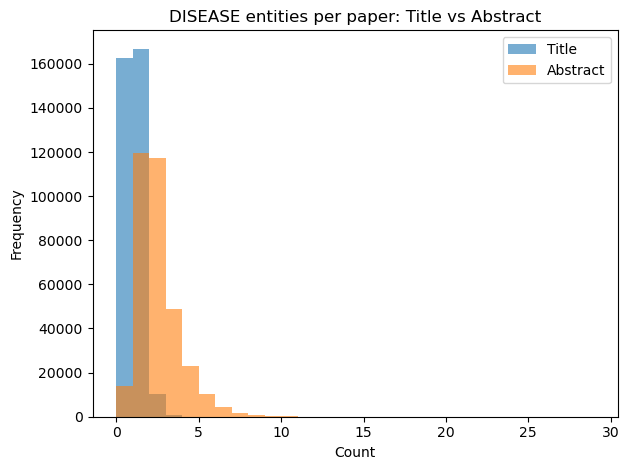

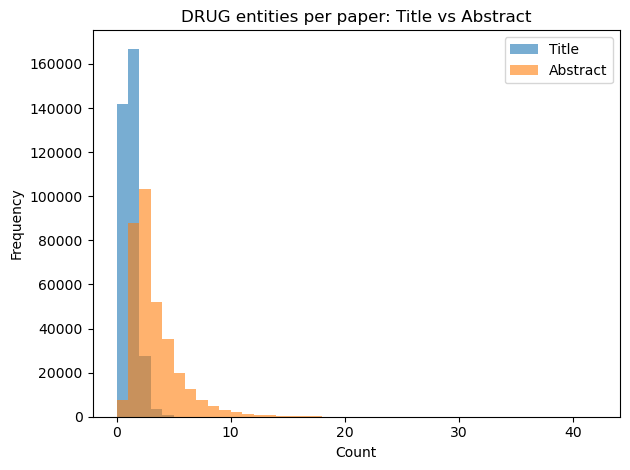

/sctmp/sdonev/ipykernel_1837655/1505242955.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["count_disease_in_title"], df["count_disease_in_abstract"]],


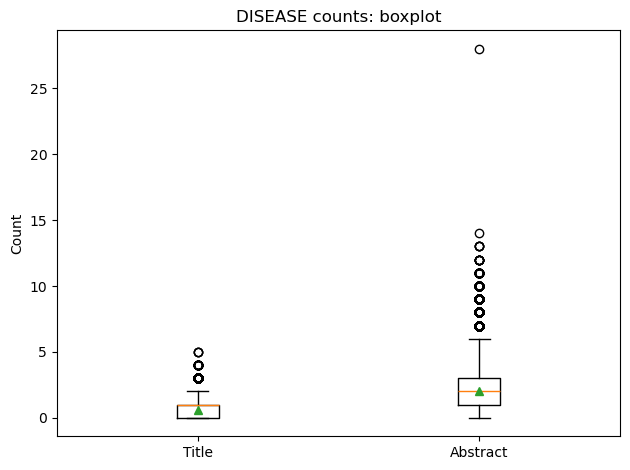

/sctmp/sdonev/ipykernel_1837655/1505242955.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["count_drug_in_title"], df["count_drug_in_abstract"]],


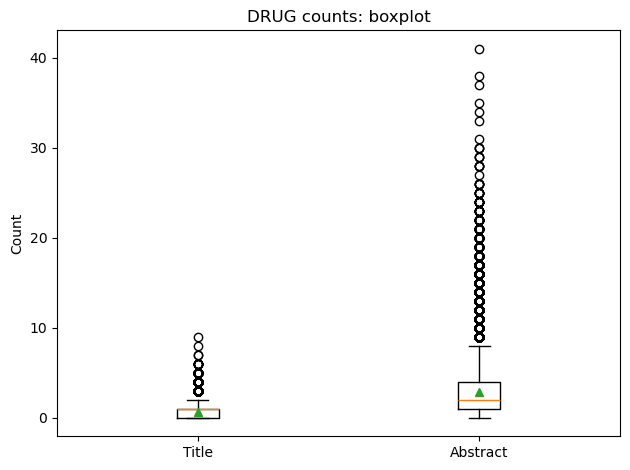

In [26]:
def _safe_bins(series):
    s = pd.to_numeric(series, errors="coerce").fillna(0).astype(int)
    m = int(s.max()) if len(s) else 0
    return range(0, m + 2)  # inclusive of max

# 1) DISEASE histogram: title vs abstract
plt.figure()
plt.hist(df["count_disease_in_title"], bins=_safe_bins(df["count_disease_in_title"]), alpha=0.6, label="Title")
plt.hist(df["count_disease_in_abstract"], bins=_safe_bins(df["count_disease_in_abstract"]), alpha=0.6, label="Abstract")
plt.title("DISEASE entities per paper: Title vs Abstract")
plt.xlabel("Count"); plt.ylabel("Frequency"); plt.legend(); plt.tight_layout(); plt.show()

# 2) DRUG histogram: title vs abstract
plt.figure()
plt.hist(df["count_drug_in_title"], bins=_safe_bins(df["count_drug_in_title"]), alpha=0.6, label="Title")
plt.hist(df["count_drug_in_abstract"], bins=_safe_bins(df["count_drug_in_abstract"]), alpha=0.6, label="Abstract")
plt.title("DRUG entities per paper: Title vs Abstract")
plt.xlabel("Count"); plt.ylabel("Frequency"); plt.legend(); plt.tight_layout(); plt.show()

# 3) DISEASE boxplot
plt.figure()
plt.boxplot([df["count_disease_in_title"], df["count_disease_in_abstract"]],
            labels=["Title","Abstract"], showmeans=True)
plt.title("DISEASE counts: boxplot"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

# 4) DRUG boxplot
plt.figure()
plt.boxplot([df["count_drug_in_title"], df["count_drug_in_abstract"]],
            labels=["Title","Abstract"], showmeans=True)
plt.title("DRUG counts: boxplot"); plt.ylabel("Count"); plt.tight_layout(); plt.show()


#### q: if there is only one drug or disease mentioned in the title -> is it enough to keep as "main" study targets? or is there more info relevant from the abstract?

In [27]:
df_filtered = included_with_preds_text_analysis.query("count_disease_in_title > 0 or count_drug_in_title > 0")
df_filtered

,PMID,source_label,ner_prediction_BioLinkBERT-base_normalized,Text,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,title,count_disease_in_title,count_drug_in_title,disease_in_title,drug_in_title,count_disease_in_abstract,count_drug_in_abstract,disease_in_abstract,drug_in_abstract
0,10063484,cadmus,"[(76, 97, DISEASE, immobilization stress), (14...",The Ca2+ channel blockade changes the behavior...,immobilization stress,-1,Calcium Channels|Nifedipine,C0006685|C0028066,The Ca2+ channel blockade changes the behavior...,1,0,[immobilization stress],[],1,2,[immobilization stress],"[ca2 + channel, nifedipine]"
2,10068163,cadmus,"[(11, 24, DRUG, kappa opioids), (152, 182, DRU...",Effects of kappa opioids in the inflamed rat c...,colitis|inflammatory bowel disease,MONDO:0005292|MONDO:0005265,delta-ora|kappa-oras|Morphine|Naloxone|kappa o...,-1|-1|C0026549|C0027358|-1|C0294405|C0165396|-...,Effects of kappa opioids in the inflamed rat c...,0,1,[],[kappa opioids],2,14,"[inflammatory bowel disease, colonic inflammat...","[kappa - opioid receptor agonists, oras, mu - ..."
3,10068171,cadmus,"[(4, 33, DRUG, kappa opioid agonist gr89 , 696...","The kappa opioid agonist GR89,696 blocks hyper...",neuritis|hyperalgesia and allodynia|peripheral...,MONDO:0002122|-1|MONDO:0005244|MONDO:0044745|-...,kappa-1 agonist u69593|GR 89696|kappa-2 opioid...,-1|C0120253|-1|-1|C0120253|C0027358,"The kappa opioid agonist GR89,696 blocks hyper...",4,0,"[hyperalgesia, allodynia, peripheral neuritis,...",[],6,6,"[hyperalgesia and allodynia, nerve injury, neu...","[kappa opioid agonist gr89 , 696, gr89696, kap..."
4,10068174,cadmus,"[(42, 69, DISEASE, trigeminal neuropathic pain...",Pharmacological studies on a rat model of trig...,trigeminal paraesthesias|neuralgia|trigeminal ...,-1|MONDO:0021667|MONDO:0008599,tricyclic antidepressants|Clomipramine|Baclofe...,-1|C0009010|C0004609|C0026549|C0006949|C008197...,Pharmacological studies on a rat model of trig...,1,4,[trigeminal neuropathic pain],"[baclofen, carbamazepine, morphine, tricyclic ...",4,8,"[trigeminal neuralgia, neuropathic pain, trige...","[alphacaine, morphine, tricyclic antidepressan..."
5,10069682,cadmus,"[(14, 24, DRUG, irbesartan), (30, 39, DRUG, ca...",Comparison of irbesartan with captopril effect...,cardiac hypertrophy|heart failure|hyperostosis...,-1|MONDO:0005252|MONDO:0002185|MONDO:0005044,irbesartan|at1r antagonist|angiotensin ii subt...,C0288171|-1|-1|C0960880|-1|C0006938,Comparison of irbesartan with captopril effect...,2,2,"[cardiac hypertrophy, heart failure]","[irbesartan, captopril]",4,6,"[hypertension, cardiac hypertrophy, hypertroph...",[angiotensin ii subtype 1 receptor ( at1r ) an...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340412,9989983,bioc_json,"[(68, 105, DRUG, granulocyte colony - stimulat...",Sustained receptor activation and hyperprolife...,severe congenital neutropenia,MONDO:0018542,filgrastim Injection|Granulocyte colony stimul...,C4020095|C0079459,Sustained receptor activation and hyperprolife...,0,2,[],"[granulocyte colony-stimulating factor, g-csf]",2,2,"[severe congenital neutropenia, scn]","[g - csf, g csf]"
340414,21801587,bioc_json,"[(51, 73, DISEASE, traumatic brain injury), (2...",Endothelin and the neurovascular unit in pedia...,brain injury|traumatic brain injury,MONDO:0043510|MONDO:0858950,BQ-123|BQ-123,C0379142|C0379142,Endothelin and the neurovascular unit in pedia...,1,0,[traumatic brain injury],[],1,2,[brain injury],"[endothelin - 1 antagonist bq - 123, bq - 123]"
340415,25188549,bioc_json,"[(0, 5, DRUG, xenon), (103, 125, DISEASE, trau...",Xenon improves neurologic outcome and reduces ...,mechanical brain lesion|traumatic brain injury,-1|MONDO:0858950,Xenon|Xenon,C0043339|C0043339,Xenon improves neurologic outcome and reduces ...,1,1,[traumatic brain injury],[xenon],3,2,"[traumatic brain injury, mechanical brain lesi...","[gas xenon, xenon]"
340416,30673266,bioc_json,"[(99, 114, DISEASE, ischem

In [28]:
included_with_preds_text_analysis_sample = df_filtered.sample(50, random_state=42)
count_cols = ['PMID' , 'ner_prediction_BioLinkBERT-base_normalized' , 'title'] + [
    "count_disease_in_title",
    "count_drug_in_title",
    "disease_in_title",
    "drug_in_title",
    "count_disease_in_abstract",
    "count_drug_in_abstract",
    "disease_in_abstract",
    "drug_in_abstract",
] 


In [29]:
included_with_preds_text_analysis_sample[count_cols].to_csv("ds_analyse_entities_in_title_50_sample.csv", index=False)